In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import TypedDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser

import random


In [2]:

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.0)
print("Libraries loaded and LLM initialized.")

Libraries loaded and LLM initialized.


In [3]:
def load_nsl_kdd_raw(filepath):
    print("Loading raw NSL-KDD dataset...")
    columns = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
        'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
        'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
        'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
        'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
        'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
        'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
        'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
    ]
    
    try:
        df = pd.read_csv(filepath, names=columns, index_col=False)
        if df.shape[1] > 42:
            df = df.iloc[:, :42]
    except FileNotFoundError:
        print("[WARNING] File not found. Generating synthetic fallback data...")
        np.random.seed(42)
        df = pd.DataFrame(np.random.rand(1000, 41), columns=columns[:-1])
        df['protocol_type'] = np.random.choice(['tcp', 'udp', 'icmp'], 1000)
        df['service'] = np.random.choice(['http', 'ftp', 'private'], 1000)
        df['flag'] = np.random.choice(['SF', 'S0', 'REJ'], 1000)
        df['label'] = np.random.choice(['normal', 'neptune', 'smurf'], 1000, p=[0.53, 0.35, 0.12])

    df['is_anomaly'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
    X_raw = df.drop(columns=['label', 'is_anomaly'])
    y = df['is_anomaly']
    return X_raw, y



In [4]:
filepath = 'KDDTrain+.txt' 
X_raw, y = load_nsl_kdd_raw(filepath)

# STRICT SPLIT: 80% Train (for optimization), 20% Test (for final report)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Data split complete. Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

Loading raw NSL-KDD dataset...
Data split complete. Train shape: (100778, 41), Test shape: (25195, 41)


C:\Users\harsh\AppData\Local\Temp\ipykernel_13940\849368473.py:17: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(filepath, names=columns, index_col=False)


In [5]:
class OptimizerState(TypedDict):
    iteration: int
    current_guideline: str       # A natural language prompt, NOT python code
    current_fpr: float           
    current_recall: float        
    scheduler_instruction: str   

In [6]:
def generate_rule_node(state: OptimizerState):
    """The LLM writes a set of instructions/guidelines for another LLM to follow."""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a Cybersecurity AI optimizing an Intrusion Detection Prompt.
        Your previous detection guideline had a False Positive Rate of {fpr} and Recall of {recall}.
        
        SCHEDULER INSTRUCTION: {instruction}
        
        CRITICAL DATA CONSTRAINTS:
        The network logs you are analyzing DO NOT contain IP addresses or Port numbers. 
        You MUST base your rules ONLY on the following exact features from the NSL-KDD dataset:
        
        1. Basic Features: 'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes'
        2. Content Features: 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login'
        3. Traffic Features (Time-based): 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate'
        4. Host-based Traffic Features: 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
        
        Write a concise, plain-English set of instructions on how to spot an anomaly using ONLY those specific features. Do not mention IPs or ports.
        """),
        ("human", "Previous Guideline:\n{guideline}\n\nWrite the updated plain-English guideline now:")
    ])
    
    chain = prompt | llm | StrOutputParser()
    new_guideline = chain.invoke({
        "fpr": state.get("current_fpr", "N/A"),
        "recall": state.get("current_recall", "N/A"),
        "instruction": state.get("scheduler_instruction", "Initial Zero-Shot. Write a broad guideline based on duration and bytes."),
        "guideline": state.get("current_guideline", "Flag anything that looks suspicious.")
    })
    
    return {"current_guideline": new_guideline, "iteration": state.get("iteration", 0) + 1}

In [7]:

def textualize_row(row):
    return (f"Protocol: {row['protocol_type']}, Service: {row['service']}, Flag: {row['flag']}, "
            f"Duration: {row['duration']}, Src Bytes: {row['src_bytes']}, Dst Bytes: {row['dst_bytes']}, "
            f"Failed Logins: {row['num_failed_logins']}, Serror Rate: {row['serror_rate']}")

In [8]:
import random

def evaluate_rule_node(state: OptimizerState):
    """Uses the LLM directly to evaluate a small batch of network logs."""
    
    guideline = state["current_guideline"]
    
    # Stratified sample of 20 logs
    X_subset, _, y_subset, _ = train_test_split(
        X_train_raw, y_train, train_size=20, stratify=y_train, random_state=random.randint(0, 1000)
    )
    
    predictions = []
    
    # 1. UPGRADED PROMPT: Make the formatting rules violently clear to the LLM
    detector_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an Intrusion Detection System. 
        Follow these guidelines to classify the log:
        {guidelines}
        
        CRITICAL FORMATTING INSTRUCTION: 
        You MUST output EXACTLY ONE CHARACTER.
        Output '1' if it is an anomaly.
        Output '0' if it is normal.
        DO NOT EXPLAIN. DO NOT ADD PUNCTUATION."""),
        ("human", "Network Log:\n{log}\n\nPrediction (0 or 1):")
    ])
    detector_chain = detector_prompt | llm | StrOutputParser()
    
    print(f"      [Evaluating {len(X_subset)} logs using the LLM directly...]")
    
    for idx, row in X_subset.iterrows():
        try:
            text_log = textualize_row(row) 
            response = detector_chain.invoke({
                "guidelines": guideline,
                "log": text_log
            }).strip()
            
            # 2. BULLETPROOF PARSING: Strict checking
            if '1' in response and '0' not in response:
                pred = 1
            elif '0' in response and '1' not in response:
                pred = 0
            else:
                # If the LLM hallucinates numbers like "100" or answers weirdly, fail safely to 0
                pred = 0
                
        except Exception as e:
            pred = 0 
            
        predictions.append(pred)
            
    # 3. SAFETY NET FOR SKLEARN
    try:
        # Force lists to strict standard Python integers to satisfy sklearn
        y_true_clean = y_subset.astype(int).tolist()
        predictions_clean = [int(p) for p in predictions]
        
        tn, fp, fn, tp = confusion_matrix(y_true_clean, predictions_clean, labels=[0, 1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
    except Exception as e:
        print(f"      [!] Metric Calculation Failed during this loop: {e}")
        # Heavily penalize the loop so the scheduler tells the LLM to fix it
        fpr, recall = 1.0, 0.0 
        
    return {"current_fpr": fpr, "current_recall": recall}

In [9]:
def textual_scheduler_node(state: OptimizerState):
    fpr = state["current_fpr"]
    recall = state["current_recall"]
    
    if fpr > 0.05:
        instruction = "LEARNING RATE: HIGH. The guideline is too broad. Instruct the detector to be much stricter."
    elif fpr > 0.00 and fpr <= 0.05:
        instruction = "LEARNING RATE: LOW. Minor tweaks only. Slightly restrict the limits."
    elif recall < 0.80 and fpr == 0:
        instruction = "LEARNING RATE: MEDIUM. Broaden the instructions safely to catch more attacks."
    else:
        instruction = "LEARNING RATE: ZERO. Stop optimization."
    return {"scheduler_instruction": instruction}



In [19]:
def should_continue(state: OptimizerState):
    """Routing logic to decide if we stop or keep looping."""
    # CHANGE: Stop after 40 iterations to allow for deeper optimization
    if state["iteration"] > 2: 
        return "end"
    
    # Stop early if we achieve our perfect M3 goal
    if state["current_fpr"] == 0.0 and state["current_recall"] >= 0.85: 
        return "end"
        
    return "continue"

In [20]:
# Compile Graph
workflow = StateGraph(OptimizerState)
workflow.add_node("generator", generate_rule_node)
workflow.add_node("evaluator", evaluate_rule_node)
workflow.add_node("scheduler", textual_scheduler_node)

workflow.set_entry_point("generator")
workflow.add_edge("generator", "evaluator")
workflow.add_conditional_edges("evaluator", should_continue, {"continue": "scheduler", "end": END})
workflow.add_edge("scheduler", "generator")

adaptive_textgrad_app = workflow.compile()
print("Adaptive TextGrad Architecture Compiled.")

Adaptive TextGrad Architecture Compiled.


In [21]:
import time

# Initialize the starting memory
initial_state = {
    "iteration": 0,
    "current_guideline": "Flag any suspicious activity based on standard network anomaly indicators.",
    "current_fpr": 1.0,
    "current_recall": 0.0,
    "scheduler_instruction": "Initial Zero-Shot Attempt. Write a broad plain-English guideline based on duration and bytes."
}

print("Initiating Adaptive TextGrad Optimization Loop on Training Data...\n")
# config = {"recursion_limit": 6} 
final_event = None

# NEW: Create a local tracker to merge all the graph's updates
current_memory = initial_state.copy()

try:
    # for event in adaptive_textgrad_app.stream(initial_state, config):
    for event in adaptive_textgrad_app.stream(initial_state):
        final_event = event
        for node_name, state_update in event.items():
            
            # NEW: Continuously update our local memory with the fresh data
            current_memory.update(state_update)
            
            # Now we pull from 'current_memory' instead of the fragmented 'state_update'
            if node_name == "scheduler":
                print(f"\n--- [ ITERATION {current_memory['iteration']} SUMMARY ] ---")
                
                print("\nGENERATED GUIDELINE:")
                print(current_memory["current_guideline"].strip())
                
                print(f"\nEVALUATION METRICS:")
                print(f"   FPR: {current_memory['current_fpr']:.4f} | Recall: {current_memory['current_recall']:.4f}")
                
                print(f"\nSCHEDULER INSTRUCTION (For next iteration):")
                print(f"   '{current_memory['scheduler_instruction']}'")
                print("-" * 50)
                
                print("⏳ Pausing for 3 seconds to prevent API Rate Limit...")
                time.sleep(3)

    print("\n✅ === OPTIMIZATION CONVERGED ===")
    # Extract from our tracked memory
    best_guideline = current_memory["current_guideline"] 
    print("\n🏆 Best Guideline Extracted and ready for Test Set evaluation!")

except Exception as e:
    print(f"\n API or Execution Error Encountered: {e}")
    print("Stopping loop early, but saving the last known good state...")
    
    # Extract from tracked memory if it crashes
    best_guideline = current_memory.get("current_guideline", "Flag any suspicious activity.")
    print("\n🏆 Partial Best Guideline Extracted despite the error!")

Initiating Adaptive TextGrad Optimization Loop on Training Data...

      [Evaluating 20 logs using the LLM directly...]

--- [ ITERATION 1 SUMMARY ] ---

GENERATED GUIDELINE:
**Updated Anomaly Detection Guideline**

**Duration-Based Indicators:**

1. **Short Duration Attacks**: Flag any connections lasting less than 1 second, as they may indicate a potential attack.
2. **Long Duration Sessions**: Identify sessions lasting more than 10 minutes, as they may indicate a prolonged attack or unauthorized access.

**Bytes-Based Indicators:**

1. **High Traffic Volume**: Flag any connections with more than 1000 bytes sent from the source or destination within a single minute.
2. **Low Traffic Volume**: Identify connections with less than 10 bytes sent from the source or destination within a single minute, as they may indicate a potential attack.

**Protocol and Service Indicators:**

1. **Uncommon Protocols**: Flag any connections using protocols other than TCP, UDP, or ICMP, as they may indi


--- FINAL M3 EVALUATION ON UNSEEN TEST DATA ---
🏆 Final Optimized Guideline being tested:
--------------------------------------------------
**Updated Anomaly Detection Guideline**

**Duration-Based Indicators:**

1. **Extremely Short Duration Attacks**: Flag any connections lasting less than 0.5 seconds, as they may indicate a potential attack.
2. **Prolonged Sessions**: Identify sessions lasting more than 15 minutes, as they may indicate a prolonged attack or unauthorized access.

**Bytes-Based Indicators:**

1. **Excessive Traffic Volume**: Flag any connections with more than 5000 bytes sent from the source or destination within a single minute.
2. **Abnormally Low Traffic Volume**: Identify connections with less than 5 bytes sent from the source or destination within a single minute, as they may indicate a potential attack.

**Protocol and Service Indicators:**

1. **Uncommon Protocols**: Flag any connections using protocols other than TCP, UDP, or ICMP, as they may indicate a pot

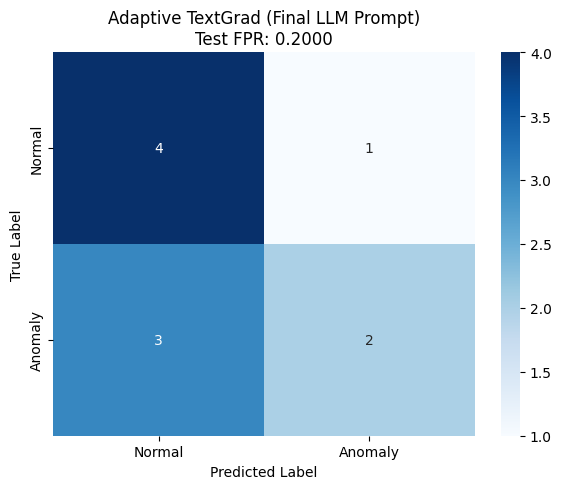

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("\n--- FINAL M3 EVALUATION ON UNSEEN TEST DATA ---")

# 1. Use 'best_guideline' directly from the previous cell's memory!
final_guideline = best_guideline 
print("🏆 Final Optimized Guideline being tested:")
print(f"--------------------------------------------------\n{final_guideline}\n--------------------------------------------------")

# 2. Sample the Test Set (CRITICAL for API limits)
sample_size = 10 
print(f"\nEvaluating on {sample_size} unseen test logs to prevent API rate limits...")

X_test_subset, _, y_test_subset, _ = train_test_split(
    X_test_raw, y_test, train_size=sample_size, stratify=y_test, random_state=42
)

# 3. Set up the LLM Detector (with strict formatting instructions)
detector_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an Intrusion Detection System. 
    Follow these guidelines to classify the log:
    {guidelines}
    
    CRITICAL FORMATTING INSTRUCTION: 
    You MUST output EXACTLY ONE CHARACTER.
    Output '1' if it is an anomaly.
    Output '0' if it is normal.
    DO NOT EXPLAIN. DO NOT ADD PUNCTUATION."""),
    ("human", "Network Log:\n{log}\n\nPrediction (0 or 1):")
])
detector_chain = detector_prompt | llm | StrOutputParser()

# 4. Generate Predictions using the LLM with BULLETPROOF parsing
test_predictions = []
for idx, row in X_test_subset.iterrows():
    text_log = textualize_row(row) # Use your M2 text conversion
    
    try:
        response = detector_chain.invoke({
            "guidelines": final_guideline,
            "log": text_log
        }).strip()
        
        # Bulletproof parsing to prevent the "1001" Unknown Targets error
        if '1' in response and '0' not in response:
            pred = 1
        elif '0' in response and '1' not in response:
            pred = 0
        else:
            pred = 0 # Default to normal if LLM hallucinates
            
    except Exception as e:
        pred = 0 
        
    test_predictions.append(pred)
    time.sleep(1) # 1-second pause to keep the API happy

# Force lists to standard integers for scikit-learn
y_test_clean = y_test_subset.astype(int).tolist()

# 5. Calculate Final Metrics
tn, fp, fn, tp = confusion_matrix(y_test_clean, test_predictions, labels=[0, 1]).ravel()
final_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"\nFinal Test False Positive Rate (FPR): {final_fpr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clean, test_predictions, target_names=['Normal (0)', 'Anomaly (1)']))

# 6. Plotting the Final Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
ax.set_title(f"Adaptive TextGrad (Final LLM Prompt)\nTest FPR: {final_fpr:.4f}")
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()